# EECS 6320 — Q2 Deliverable  
## Preprocessing + Baseline Bias (21st Mortgage Corporation)

**Implementing Q2 milestone** for the final project:
- Preprocess the 21st Mortgage Corporation data
- Train a **baseline Random Forest** model for `action_taken`
- Measure **baseline bias** before any debiasing
- Prepare a clean foundation for **Q3 debiasing methods**

### Q2 Objective
The goal is to **preprocess the dataset and find the baseline bias**. The project also assigns this responsibility to the preprocessing / baseline-model track.

### Modeling Choice
To make Q2 precise and reproducible, this notebook converts `action_taken` into a **binary approval task**:
- `1` → **Approved / originated**
- `3` → **Denied**

All other action codes are excluded from the Q2 baseline so that the fairness analysis is focused on a clean approval-vs-denial decision.

### Sensitive Attributes Used
Primary:
- `applicant_sex`
- `applicant_race_1`

Secondary:
- `applicant_age`

### Fairness Metrics Reported
- **Group Disparity Difference** (demographic parity gap / selection-rate gap)
- **Equal Opportunity Gap** (TPR gap)
- **False Positive Rate Gap**

---


In [1]:
# Core imports
import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
from pathlib import Path
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
from sklearn.neighbors import NearestNeighbors

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

# Set random seed
SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

In [2]:
# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Locate dataset automatically (works locally and in Colab)
candidate_paths = [
    Path("/mnt/data/21stMortgageCorporation_header.csv"),
    Path("./21stMortgageCorporation_header.csv"),
    Path("/content/21stMortgageCorporation_header.csv"),
    Path("/content/drive/MyDrive/EECS6320/Dataset/21stMortgageCorporation_header.csv"),
]

# Check all data paths to find applicable path to csv
DATA_PATH = None
for p in candidate_paths:
    if p.exists():
        DATA_PATH = p
        break

# If no path is found, raise error
if DATA_PATH is None:
    raise FileNotFoundError("21stMortgageCorporation_header.csv not found. Upload it or update candidate_paths.")

# Set an output directory for results
OUT_DIR = Path("/mnt/data/MMD_Distribution_Outputs") if Path("/mnt/data").exists() else Path("./MMD_Distribution_Outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Print input and output information
print(f"Using data file: {DATA_PATH}")
print(f"Saving outputs to: {OUT_DIR.resolve()}")

Mounted at /content/drive
Using data file: /content/drive/MyDrive/EECS6320/Dataset/21stMortgageCorporation_header.csv
Saving outputs to: /content/MMD_Distribution_Outputs


## 1. Define Q2 columns and target setup

The project draft already identifies a baseline feature subset.  
For Q2 we keep those baseline features, evaluate fairness on sex/race/age, and use `action_taken` as the target.


In [3]:
# Define the target column
TARGET_COL = "action_taken"

# Define numeric columns
BASELINE_NUMERIC_COLS = [
    "loan_amount",
    "income",
    "property_value",
    "loan_term",
]

# Define categorical columns
BASELINE_CATEGORICAL_COLS = [
    "occupancy_type",
    "state_code",
    "county_code",
    "applicant_credit_scoring_model",
    "debt_to_income_ratio",
    "interest_only_payment",
]

# Define sensitive attribute columns
SENSITIVE_COLS = [
    "applicant_sex",
    "applicant_race_1",
    "applicant_age",
]

# Combine all columns
ALL_REQUIRED_COLS = BASELINE_NUMERIC_COLS + BASELINE_CATEGORICAL_COLS + SENSITIVE_COLS + [TARGET_COL]

# Print all columns
ALL_REQUIRED_COLS

['loan_amount',
 'income',
 'property_value',
 'loan_term',
 'occupancy_type',
 'state_code',
 'county_code',
 'applicant_credit_scoring_model',
 'debt_to_income_ratio',
 'interest_only_payment',
 'applicant_sex',
 'applicant_race_1',
 'applicant_age',
 'action_taken']

In [4]:
# Read only required columns.
# IMPORTANT: the uploaded 21st Mortgage Corporation file is pipe-delimited, not comma-delimited.
raw_df = pd.read_csv(DATA_PATH, sep="|", usecols=ALL_REQUIRED_COLS, dtype="string")

# Print dataframe statistics and header
print("Raw shape:", raw_df.shape)
raw_df.head()

Raw shape: (163986, 14)


,occupancy_type,loan_amount,action_taken,state_code,county_code,applicant_race_1,applicant_sex,applicant_age,income,applicant_credit_scoring_model,debt_to_income_ratio,loan_term,interest_only_payment,property_value
0,1,105000,3,LA,22031,5,1,25-34,<NA>,9,<NA>,276,2,<NA>
1,1,55000,6,SC,45035,7,4,8888,<NA>,9,<NA>,180,2,55000
2,1,55000,6,NC,37081,7,4,8888,<NA>,9,<NA>,180,2,55000
3,1,45000,6,NC,37183,7,4,8888,<NA>,9,<NA>,144,2,45000
4,1,35000,6,TX,48121,7,4,8888,<NA>,9,<NA>,120,2,35000


## 2. Clean the raw data

Cleaning steps:
1. Replace `?` and blank strings with missing values.
2. Trim whitespace.
3. Keep only the valid Q2 target classes (`1` = approved, `3` = denied).
4. Keep valid sensitive attribute categories:
   - sex: `1`, `2`
   - race: `2`, `3`, `5`  → Asian, Black, White
   - age: valid ordinal age buckets only
5. Convert numeric feature columns to numeric.
6. Create a binary target:
   - approved = 1
   - denied = 0


In [5]:
# Clean raw strings
df = raw_df.copy()
df = df.replace(["?", "<NA>", "NA", "N/A", "null", "None", ""], np.nan)
df = df.replace(r"^\s*$", np.nan, regex=True)

# For all columns, remove whitespace
for col in df.columns:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

# Keep valid target values for a clean approval-vs-denial baseline
df = df[df[TARGET_COL].isin(["1", "3"])].copy()

# Keep valid sensitive-attribute categories used in the current project design
valid_ages = ["<25", "25-34", "35-44", "45-54", "55-64", "65-74", ">74"]
df = df[df["applicant_sex"].isin(["1", "2"])].copy()
df = df[df["applicant_race_1"].isin(["2", "3", "5"])].copy()
df = df[df["applicant_age"].isin(valid_ages)].copy()

# Convert numeric baseline columns
for col in BASELINE_NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Binary target: 1=approved, 0=denied
df["target"] = df[TARGET_COL].map({"1": 1, "3": 0}).astype("int64")

# Cast categoricals explicitly
for col in BASELINE_CATEGORICAL_COLS + SENSITIVE_COLS:
    df[col] = df[col].astype("object")

# Force any lingering pandas NA to np.nan
df = df.replace({pd.NA: np.nan})

# Print preprocessing results
print("Filtered / cleaned shape:", df.shape)
print("\nTarget distribution (1=approved, 0=denied):")
print(df["target"].value_counts(dropna=False))
print("\nMissing values after filtering:")
print(df[ALL_REQUIRED_COLS].isna().sum().sort_values(ascending=False))

Filtered / cleaned shape: (85241, 15)

Target distribution (1=approved, 0=denied):
target
0    62986
1    22255
Name: count, dtype: int64

Missing values after filtering:
property_value                    1731
income                            1730
debt_to_income_ratio              1723
loan_amount                          0
occupancy_type                       0
loan_term                            0
state_code                           0
county_code                          0
applicant_credit_scoring_model       0
interest_only_payment                0
applicant_sex                        0
applicant_race_1                     0
applicant_age                        0
action_taken                         0
dtype: int64


In [6]:
# Save cleaned Q2 dataset for reproducibility
clean_q2_path = OUT_DIR / "q2_cleaned_dataset.csv"
df.to_csv(clean_q2_path, index=False)
print(f"Saved cleaned dataset to: {clean_q2_path}")

Saved cleaned dataset to: MMD_Distribution_Outputs/q2_cleaned_dataset.csv


## 3. Train/test split

Sensitive attributes are kept **for evaluation**.  
The baseline model itself uses only the baseline feature subset, so Q2 can evaluate fairness externally rather than baking protected attributes directly into the model.


In [7]:
# Define X, Y, and sensitive dataframe
X = df[BASELINE_NUMERIC_COLS + BASELINE_CATEGORICAL_COLS + SENSITIVE_COLS].copy()
y = df["target"].copy()

# Define the train/test split percentage
test_split = 0.25

# Create train and test splits for X, Y, and sensitive.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test_split,
    random_state=SEED,
    stratify=y,
)

# Print train test split results
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).rename("proportion"))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).rename("proportion"))

Train shape: (63930, 13)
Test shape: (21311, 13)

Train target distribution:
target
0    0.738918
1    0.261082
Name: proportion, dtype: float64

Test target distribution:
target
0    0.738914
1    0.261086
Name: proportion, dtype: float64


##  4. Preprocessing pipeline + baseline Neural Networks

Why this pipeline is strong for Q2:
- numeric features are median-imputed,
- categorical features are mode-imputed and one-hot encoded,
- the train/test transformation is identical and reproducible,
- the model is a clean **baseline**, leaving debiasing work for Q3.


In [8]:
def preprocess(X_tr, X_tst):
  imp_median = SimpleImputer(missing_values=np.nan, strategy='median')
  scaler = StandardScaler()

  numeric_pipeline = Pipeline([
      ('imputer', imp_median),
      ('scaler', scaler)
  ])

  imp_categorical = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
  encoder = OneHotEncoder(handle_unknown='ignore')

  categorical_pipeline = Pipeline([
      ('imputer', imp_categorical),
      ('encoder', encoder)
  ])

  col_transformer = ColumnTransformer([
      ('numerical', numeric_pipeline, BASELINE_NUMERIC_COLS),
      ('categorical', categorical_pipeline, BASELINE_CATEGORICAL_COLS)
  ])


  X_train_processed = col_transformer.fit_transform(X_tr)
  X_test_processed = col_transformer.transform(X_tst)

  # Convert sparse → dense
  if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()

  # Convert sparse → dense
  if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()

  return X_train_processed, X_test_processed

## Create tensors

In [9]:
# Creating tensors of the data
def create_tensors(X_tr_scaled, y_tr, X_tst_scaled, y_tst):
  X_tr_tensor = torch.tensor(X_tr_scaled, dtype=torch.float32)
  y_tr_tensor = torch.tensor(y_tr.values, dtype=torch.float32)

  X_tst_tensor = torch.tensor(X_tst_scaled, dtype=torch.float32)
  y_tst_tensor = torch.tensor(y_tst.values, dtype=torch.float32)

  train_loader = DataLoader(
    TensorDataset(X_tr_tensor, y_tr_tensor),
    batch_size=256,
    shuffle=True
  )

  return X_tst_tensor, y_tst_tensor, train_loader

## Model Formation

In [10]:
class Model(nn.Module):
  def __init__(self, input_dim, h=64):
    super(Model, self).__init__()
    self.fc1 = nn.Linear(input_dim, h)
    self.fc2 = nn.Linear(h, h)
    self.out = nn.Linear(h, 1)

    self.net = nn.Sequential(
        self.fc1,
        nn.ReLU(),
        self.fc2,
        nn.ReLU(),
        self.out,
        nn.Sigmoid()
    )

  def forward(self, x):
    return self.net(x)

## Model Training

In [11]:
def model_training(input_dim, X_tst_tensor, y_tst_tensor, tr_loader):
  epochs = 50

  torch.manual_seed(42)

  model = Model(input_dim)
  criterion = nn.BCELoss()
  optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

  for epoch in range(1, epochs + 1):
    # mlp model training begins
    model.train()
    # for every batch of size (32, nfeatures)
    for X_batch, y_batch in tr_loader:
      # resetting gradients to zero
      optimizer.zero_grad()
      # forward pass
      y_pred = model(X_batch).squeeze()
      # calculating BCE loss
      loss = criterion(y_pred, y_batch)
      # back propagation
      loss.backward()
      # updating parameters using SGD
      optimizer.step()

    model.eval()
    with torch.no_grad():
      test_pred = (model(X_tst_tensor).squeeze() > 0.5).int().numpy()
      # test_pred = (test_pred > 0.5).float()

    if epoch == 1 or epoch % 5 == 0:
      print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")

  return test_pred

## Executing complete pipeline

In [12]:
def execute_pipeline(X_train, y_train, X_test, y_test):
  # Scaling features
  X_train_processed, X_test_processed = preprocess(X_train, X_test)

  # Creating tensors
  X_test_tensor, y_test_tensor, train_loader = create_tensors(X_train_processed, y_train, X_test_processed, y_test)

  # Training model
  test_pred = model_training(X_train_processed.shape[1], X_test_tensor, y_test_tensor, train_loader)

  return y_test_tensor, test_pred

y_test_tensor, test_pred = execute_pipeline(X_train, y_train, X_test, y_test)

Epoch 1/50, Loss: 0.6298
Epoch 5/50, Loss: 0.5404
Epoch 10/50, Loss: 0.4854
Epoch 15/50, Loss: 0.4462
Epoch 20/50, Loss: 0.4153
Epoch 25/50, Loss: 0.3926
Epoch 30/50, Loss: 0.4083
Epoch 35/50, Loss: 0.3679
Epoch 40/50, Loss: 0.3499
Epoch 45/50, Loss: 0.3746
Epoch 50/50, Loss: 0.3574


## 5. Baseline predictive performance

These metrics answer the question:  
**Is the baseline model functioning properly before we even talk about debiasing?**


## Prediction and Evaluation

In [13]:
def evaluation(y_tst_tensor, tst_pred):
  accuracy = accuracy_score(y_tst_tensor, tst_pred)
  bal_acc = balanced_accuracy_score(y_tst_tensor, tst_pred)
  auc = roc_auc_score(y_tst_tensor, tst_pred)
  cm = confusion_matrix(y_tst_tensor, tst_pred)

  print(f"\nTest Accuracy: {accuracy:.4f}")
  print(f"Test Balance Accuracy: {bal_acc:.4f}")
  print(f"ROC AUC Score: {auc:.4f}")
  print("\nConfusion Matrix:\n", cm)

  return accuracy, bal_acc, auc

In [14]:
accuracy, bal_acc, auc = evaluation(y_test_tensor, test_pred)


Test Accuracy: 0.8205
Test Balance Accuracy: 0.7671
ROC AUC Score: 0.7671

Confusion Matrix:
 [[13838  1909]
 [ 1917  3647]]


## 6. Build fairness evaluation table

This evaluation frame keeps:
- sensitive attributes,
- true labels,
- predicted labels,
- predicted approval probability.


In [15]:
# Create a evaluation dataframe
eval_df = X_test[SENSITIVE_COLS].copy()
eval_df["y_true"] = y_test.to_numpy()
eval_df["y_pred"] = test_pred
# eval_df["y_score"] = y_score

# Mapping for sex and race
sex_map = {"1": "Male", "2": "Female"}
race_map = {"2": "Asian", "3": "Black", "5": "White"}

# Add labels that map applicant sex and race
eval_df["sex_label"] = eval_df["applicant_sex"].map(sex_map)
eval_df["race_label"] = eval_df["applicant_race_1"].map(race_map)

# Display evaluation dataframe header
eval_df.head()

,applicant_sex,applicant_race_1,applicant_age,y_true,y_pred,sex_label,race_label
107761,1,5,25-34,0,0,Male,White
68500,2,5,35-44,0,0,Female,White
65752,2,3,35-44,0,0,Female,Black
70072,1,5,25-34,0,0,Male,White
113531,1,5,55-64,0,1,Male,White


## 7. Fairness metrics

For each group we compute:
- **Base positive rate** = actual approval rate in the test set
- **Selection rate** = predicted approval rate
- **True positive rate** = equal opportunity measure
- **False positive rate**

Then we summarize:
- **Demographic parity gap** = max selection rate − min selection rate
- **Equal opportunity gap** = max TPR − min TPR
- **FPR gap** = max FPR − min FPR


In [16]:
# Define the fairness table
def fairness_table(input_df, group_col, positive_label=1):
    rows = []

    for group_value, gdf in input_df.groupby(group_col):
        # Not applicable group or empty gdf
        if pd.isna(group_value) or len(gdf) == 0:
            continue

        # Sum positive and negative labeling
        positive_true = (gdf["y_true"] == positive_label).sum()
        negative_true = (gdf["y_true"] != positive_label).sum()

        # Find selection rate and base positive rate
        selection_rate = float((gdf["y_pred"] == positive_label).mean())
        base_positive_rate = float((gdf["y_true"] == positive_label).mean())

        # Calculate TPR
        tpr = np.nan
        if positive_true > 0:
            tpr = float(((gdf["y_pred"] == positive_label) & (gdf["y_true"] == positive_label)).sum() / positive_true)

        # Calculate FPR
        fpr = np.nan
        if negative_true > 0:
            fpr = float(((gdf["y_pred"] == positive_label) & (gdf["y_true"] != positive_label)).sum() / negative_true)

        # Append to list of rows
        rows.append({
            "group": group_value,
            "n": int(len(gdf)),
            "base_positive_rate": base_positive_rate,
            "selection_rate": selection_rate,
            "true_positive_rate": tpr,
            "false_positive_rate": fpr,
        })

    # Create new dataframe for output
    out = pd.DataFrame(rows).sort_values("group").reset_index(drop=True)
    overall_selection_rate = float((input_df["y_pred"] == positive_label).mean())
    out["selection_rate_minus_overall"] = out["selection_rate"] - overall_selection_rate
    return out

# Fairness metric summary
def fairness_gap_summary(tbl):
    return pd.Series({
        "demographic_parity_gap": float(tbl["selection_rate"].max() - tbl["selection_rate"].min()),
        "equal_opportunity_gap": float(tbl["true_positive_rate"].max() - tbl["true_positive_rate"].min()),
        "false_positive_rate_gap": float(tbl["false_positive_rate"].max() - tbl["false_positive_rate"].min()),
    })

# Calculate rates per group
sex_fairness = fairness_table(eval_df, "sex_label")
race_fairness = fairness_table(eval_df, "race_label")
age_fairness = fairness_table(eval_df, "applicant_age")

# Calculate fairness metrics per group
sex_summary = fairness_gap_summary(sex_fairness)
race_summary = fairness_gap_summary(race_fairness)
age_summary = fairness_gap_summary(age_fairness)

# Print results for sex
print("Sex fairness table")
display(sex_fairness)
print("\nSex gap summary")
display(sex_summary.to_frame(name="value"))

# Print results for race
print("\nRace fairness table")
display(race_fairness)
print("\nRace gap summary")
display(race_summary.to_frame(name="value"))

# Print results for age
print("\nAge fairness table")
display(age_fairness)
print("\nAge gap summary")
display(age_summary.to_frame(name="value"))

Sex fairness table


,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,Female,11246,0.217677,0.227814,0.631536,0.115481,-0.032896
1,Male,10065,0.309588,0.297466,0.674262,0.128508,0.036756



Sex gap summary


,value
demographic_parity_gap,0.069652
equal_opportunity_gap,0.042726
false_positive_rate_gap,0.013027



Race fairness table


...

,value
demographic_parity_gap,0.172960
equal_opportunity_gap,0.118637
false_positive_rate_gap,0.072388



Age fairness table


,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,25-34,6117,0.235736,0.251921,0.683773,0.118717,-0.008790
1,35-44,4984,0.235955,0.270265,0.710884,0.134191,0.009554
2,45-54,3678,0.277325,0.277868,0.688235,0.120391,0.017158
3,55-64,2618,0.332697,0.300611,0.656716,0.123068,0.039901
4,65-74,1211,0.337737,0.134600,0.281174,0.059850,-0.126111
5,<25,2327,0.236356,0.253975,0.672727,0.124367,-0.006735
6,>74,376,0.255319,0.279255,0.687500,0.139286,0.018545



Age gap summary


,value
demographic_parity_gap,0.166012
equal_opportunity_gap,0.429711
false_positive_rate_gap,0.079435


## 8. Visual summary

A quick visual summary for Q2:
- sex-based predicted approval rates,
- race-based predicted approval rates,
- age-based predicted approval rates.


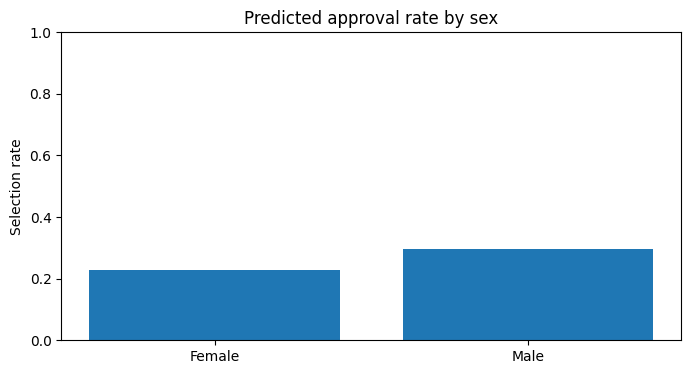

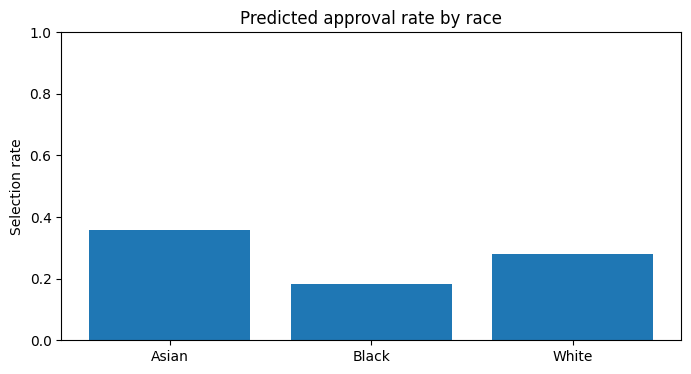

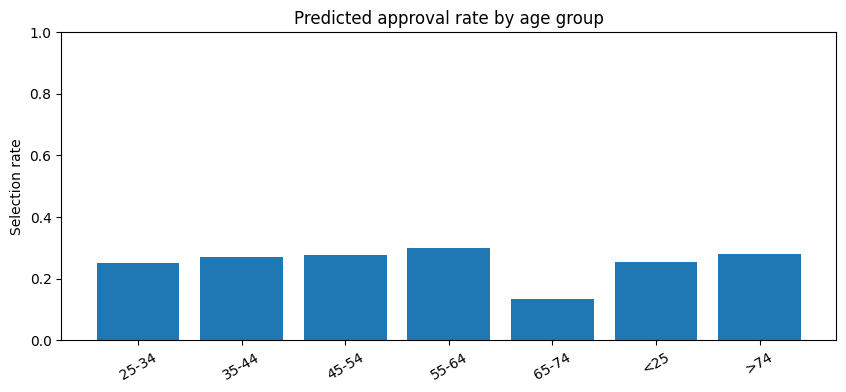

In [17]:
# Create graph for sex-based approval rates
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(sex_fairness["group"], sex_fairness["selection_rate"])
ax.set_title("Predicted approval rate by sex")
ax.set_ylabel("Selection rate")
ax.set_ylim(0, 1)
plt.show()

# Create graph for race-based approval rates
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(race_fairness["group"], race_fairness["selection_rate"])
ax.set_title("Predicted approval rate by race")
ax.set_ylabel("Selection rate")
ax.set_ylim(0, 1)
plt.show()

# Create graph for age-based approval rates
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(age_fairness["group"], age_fairness["selection_rate"])
ax.set_title("Predicted approval rate by age group")
ax.set_ylabel("Selection rate")
ax.set_ylim(0, 1)
plt.xticks(rotation=30)
plt.show()

## 9. Save Q2 result tables

Save the results for future reference.


In [18]:
# Output directory paths
sex_fairness_path = OUT_DIR / "q2_fairness_by_sex.csv"
race_fairness_path = OUT_DIR / "q2_fairness_by_race.csv"
age_fairness_path = OUT_DIR / "q2_fairness_by_age.csv"
metrics_path = OUT_DIR / "q2_model_metrics.csv"

# Convert dataframes to csv
sex_fairness.to_csv(sex_fairness_path, index=False)
race_fairness.to_csv(race_fairness_path, index=False)
age_fairness.to_csv(age_fairness_path, index=False)

# Summarize all baseline metrics into one baseline dataframe
metrics_df = pd.DataFrame([
    {"metric": "accuracy", "value": accuracy},
    {"metric": "balanced_accuracy", "value": bal_acc},
    {"metric": "roc_auc", "value": auc},
    {"metric": "sex_demographic_parity_gap", "value": float(sex_summary['demographic_parity_gap'])},
    {"metric": "sex_equal_opportunity_gap", "value": float(sex_summary['equal_opportunity_gap'])},
    {"metric": "race_demographic_parity_gap", "value": float(race_summary['demographic_parity_gap'])},
    {"metric": "race_equal_opportunity_gap", "value": float(race_summary['equal_opportunity_gap'])},
    {"metric": "age_demographic_parity_gap", "value": float(age_summary['demographic_parity_gap'])},
    {"metric": "age_equal_opportunity_gap", "value": float(age_summary['equal_opportunity_gap'])},
])

# Convert baseline dataframe to csv
metrics_df.to_csv(metrics_path, index=False)

# Print successfull save
print("Saved:")
print(" -", sex_fairness_path)
print(" -", race_fairness_path)
print(" -", age_fairness_path)
print(" -", metrics_path)

Saved:
 - MMD_Distribution_Outputs/q2_fairness_by_sex.csv
 - MMD_Distribution_Outputs/q2_fairness_by_race.csv
 - MMD_Distribution_Outputs/q2_fairness_by_age.csv
 - MMD_Distribution_Outputs/q2_model_metrics.csv


## 10. Q2 conclusion

We reached the **Q2 milestone**:

- The 21st Mortgage Corporation dataset was cleaned and filtered for a approval-vs-denial task,
- A baseline Random Forest model was trained,
- Predictive metrics were reported,
- Baseline fairness was measured across **sex**, **race**, and **age**,
- The outputs were saved so that **Q3 debiasing methods** can be compared directly against this baseline.



# MMD Distribution Alignment Method

## 1. MMD Function

RBF (Gaussian Kernel):

In [19]:
def kernel(x, y, sigma=1.0):
  dists = torch.cdist(x, y).pow(2)   # (n, m) — no intermediate tensor
  return torch.exp(-dists / (2 * sigma ** 2))

Compute MMD

In [20]:
def compute_mmd(x, y, sigma=1.0):
  Kxx = kernel(x, x, sigma).mean()
  Kyy = kernel(y, y, sigma).mean()
  Kxy = kernel(x, y, sigma).mean()
  return Kxx + Kyy - 2 * Kxy

def multi_kernel_mmd(x, y, sigmas=[1, 5, 10]):
  loss = 0
  for sigma in sigmas:
    loss += compute_mmd(x, y, sigma)
  return loss / len(sigmas)

## 2. Updated Model training

In [21]:
def model_training_mmd(input_dim, X_tst_tensor, y_tst_tensor, tr_loader, tgt_loader, lambda_mmd=1.0):
  epochs = 50

  torch.manual_seed(42)

  model = Model(input_dim)
  criterion = nn.BCELoss()
  optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

  tgt_iter = iter(tgt_loader)

  for epoch in range(1, epochs + 1):
    # mlp model training begins
    model.train()
    # for every batch of size (32, nfeatures)
    for X_batch, y_batch in tr_loader:
      # resetting gradients to zero
      optimizer.zero_grad()
      # forward pass
      y_pred = model(X_batch).squeeze()
      # calculating BCE loss
      cls_loss = criterion(y_pred, y_batch)

      # fetch next target batch, cycling if exhausted
      try:
        X_tgt, _ = next(tgt_iter)
      except StopIteration:
        tgt_iter = iter(tgt_loader)
        X_tgt, _ = next(tgt_iter)

      # MMD alignment loss between source and target features
      src_feat = model.net[:-1](X_batch)   # penultimate layer features
      tgt_feat = model.net[:-1](X_tgt)
      align_loss = multi_kernel_mmd(src_feat, tgt_feat)

      loss = cls_loss + lambda_mmd * align_loss

      # back propagation
      loss.backward()
      # updating parameters using SGD
      optimizer.step()

    model.eval()
    with torch.no_grad():
      test_pred = (model(X_tst_tensor).squeeze() > 0.5).int().numpy()
      # test_pred = (test_pred > 0.5).float()

    if epoch == 1 or epoch % 5 == 0:
      print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}, BCE: {cls_loss.item():.4f}, MMD: {align_loss.item():.4f}")

  return test_pred

In [22]:
def execute_pipeline_mmd(X_train, y_train, X_test, y_test):
  # Scaling features
  X_train_processed, X_test_processed = preprocess(X_train, X_test)

  X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
  y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
  X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)
  y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

  train_loader  = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=256, shuffle=True)

  target_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor),  batch_size=256, shuffle=True)

  pred_mmd = model_training_mmd(X_train_processed.shape[1], X_test_tensor, y_test_tensor, train_loader, target_loader, lambda_mmd=1.0)

  return y_test_tensor, pred_mmd

y_test_tensor, pred_mmd = execute_pipeline_mmd(X_train, y_train, X_test, y_test)



Epoch 1/50, Loss: 0.5886, BCE: 0.5886, MMD: 0.0000
Epoch 5/50, Loss: 0.5361, BCE: 0.5361, MMD: 0.0000
Epoch 10/50, Loss: 0.5078, BCE: 0.5073, MMD: 0.0005
Epoch 15/50, Loss: 0.4338, BCE: 0.4312, MMD: 0.0026
Epoch 20/50, Loss: 0.4024, BCE: 0.4014, MMD: 0.0010
Epoch 25/50, Loss: 0.3782, BCE: 0.3752, MMD: 0.0030
Epoch 30/50, Loss: 0.3750, BCE: 0.3740, MMD: 0.0010
Epoch 35/50, Loss: 0.4139, BCE: 0.4119, MMD: 0.0020
Epoch 40/50, Loss: 0.3973, BCE: 0.3935, MMD: 0.0039
Epoch 45/50, Loss: 0.4035, BCE: 0.4019, MMD: 0.0016
Epoch 50/50, Loss: 0.3251, BCE: 0.3245, MMD: 0.0005


## 3. Prediction and Evaluation

In [23]:
accuracy_mmd, bal_acc_mmd, auc_mmd = evaluation(y_test_tensor, pred_mmd)


Test Accuracy: 0.8196
Test Balance Accuracy: 0.7616
ROC AUC Score: 0.7616

Confusion Matrix:
 [[13904  1843]
 [ 2002  3562]]


## 4. Build fairness evaluation table

This evaluation frame keeps:
- sensitive attributes,
- true labels,
- predicted labels,
- predicted approval probability.


In [24]:
# Create a evaluation dataframe
eval_df = X_test[SENSITIVE_COLS].copy()
eval_df["y_true"] = y_test.to_numpy()
eval_df["y_pred"] = pred_mmd
# eval_df["y_score"] = y_score

# Mapping for sex and race
sex_map = {"1": "Male", "2": "Female"}
race_map = {"2": "Asian", "3": "Black", "5": "White"}

# Add labels that map applicant sex and race
eval_df["sex_label"] = eval_df["applicant_sex"].map(sex_map)
eval_df["race_label"] = eval_df["applicant_race_1"].map(race_map)

# Display evaluation dataframe header
eval_df.head()

,applicant_sex,applicant_race_1,applicant_age,y_true,y_pred,sex_label,race_label
107761,1,5,25-34,0,0,Male,White
68500,2,5,35-44,0,0,Female,White
65752,2,3,35-44,0,0,Female,Black
70072,1,5,25-34,0,0,Male,White
113531,1,5,55-64,0,1,Male,White


## 5. Fairness metrics

For each group we compute:
- **Base positive rate** = actual approval rate in the test set
- **Selection rate** = predicted approval rate
- **True positive rate** = equal opportunity measure
- **False positive rate**

Then we summarize:
- **Demographic parity gap** = max selection rate − min selection rate
- **Equal opportunity gap** = max TPR − min TPR
- **FPR gap** = max FPR − min FPR


In [25]:
# Define the fairness table
def fairness_table(input_df, group_col, positive_label=1):
    rows = []

    for group_value, gdf in input_df.groupby(group_col):
        # Not applicable group or empty gdf
        if pd.isna(group_value) or len(gdf) == 0:
            continue

        # Sum positive and negative labeling
        positive_true = (gdf["y_true"] == positive_label).sum()
        negative_true = (gdf["y_true"] != positive_label).sum()

        # Find selection rate and base positive rate
        selection_rate = float((gdf["y_pred"] == positive_label).mean())
        base_positive_rate = float((gdf["y_true"] == positive_label).mean())

        # Calculate TPR
        tpr = np.nan
        if positive_true > 0:
            tpr = float(((gdf["y_pred"] == positive_label) & (gdf["y_true"] == positive_label)).sum() / positive_true)

        # Calculate FPR
        fpr = np.nan
        if negative_true > 0:
            fpr = float(((gdf["y_pred"] == positive_label) & (gdf["y_true"] != positive_label)).sum() / negative_true)

        # Append to list of rows
        rows.append({
            "group": group_value,
            "n": int(len(gdf)),
            "base_positive_rate": base_positive_rate,
            "selection_rate": selection_rate,
            "true_positive_rate": tpr,
            "false_positive_rate": fpr,
        })

    # Create new dataframe for output
    out = pd.DataFrame(rows).sort_values("group").reset_index(drop=True)
    overall_selection_rate = float((input_df["y_pred"] == positive_label).mean())
    out["selection_rate_minus_overall"] = out["selection_rate"] - overall_selection_rate
    return out

# Fairness metric summary
def fairness_gap_summary(tbl):
    return pd.Series({
        "demographic_parity_gap": float(tbl["selection_rate"].max() - tbl["selection_rate"].min()),
        "equal_opportunity_gap": float(tbl["true_positive_rate"].max() - tbl["true_positive_rate"].min()),
        "false_positive_rate_gap": float(tbl["false_positive_rate"].max() - tbl["false_positive_rate"].min()),
    })

# Calculate rates per group
sex_fairness = fairness_table(eval_df, "sex_label")
race_fairness = fairness_table(eval_df, "race_label")
age_fairness = fairness_table(eval_df, "applicant_age")

# Calculate fairness metrics per group
sex_summary = fairness_gap_summary(sex_fairness)
race_summary = fairness_gap_summary(race_fairness)
age_summary = fairness_gap_summary(age_fairness)

# Print results for sex
print("Sex fairness table")
display(sex_fairness)
print("\nSex gap summary")
display(sex_summary.to_frame(name="value"))

# Print results for race
print("\nRace fairness table")
display(race_fairness)
print("\nRace gap summary")
display(race_summary.to_frame(name="value"))

# Print results for age
print("\nAge fairness table")
display(age_fairness)
print("\nAge gap summary")
display(age_summary.to_frame(name="value"))

Sex fairness table


,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,Female,11246,0.217677,0.221145,0.614379,0.111730,-0.032480
1,Male,10065,0.309588,0.289916,0.660462,0.123759,0.036291



Sex gap summary


,value
demographic_parity_gap,0.068770
equal_opportunity_gap,0.046083
false_positive_rate_gap,0.012029



Race fairness table


...

,value
demographic_parity_gap,0.179352
equal_opportunity_gap,0.143672
false_positive_rate_gap,0.074956



Age fairness table


,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,25-34,6117,0.235736,0.244074,0.669209,0.112941,-0.009551
1,35-44,4984,0.235955,0.259831,0.686224,0.128151,0.006207
2,45-54,3678,0.277325,0.270527,0.672549,0.116253,0.016903
3,55-64,2618,0.332697,0.292972,0.638347,0.120778,0.039347
4,65-74,1211,0.337737,0.137903,0.283619,0.063591,-0.115722
5,<25,2327,0.236356,0.248388,0.656364,0.122116,-0.005236
6,>74,376,0.255319,0.292553,0.739583,0.139286,0.038928



Age gap summary


,value
demographic_parity_gap,0.155069
equal_opportunity_gap,0.455965
false_positive_rate_gap,0.075695


## 6. Visual summary

A quick visual summary for MMD:
- sex-based predicted approval rates,
- race-based predicted approval rates,
- age-based predicted approval rates.


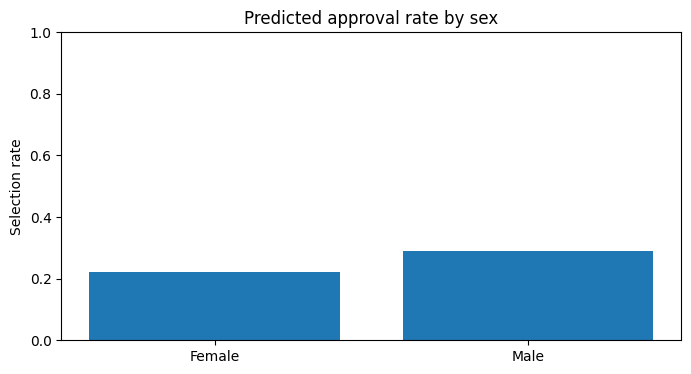

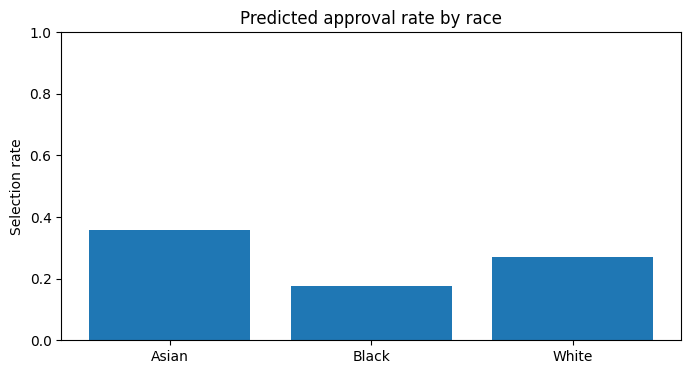

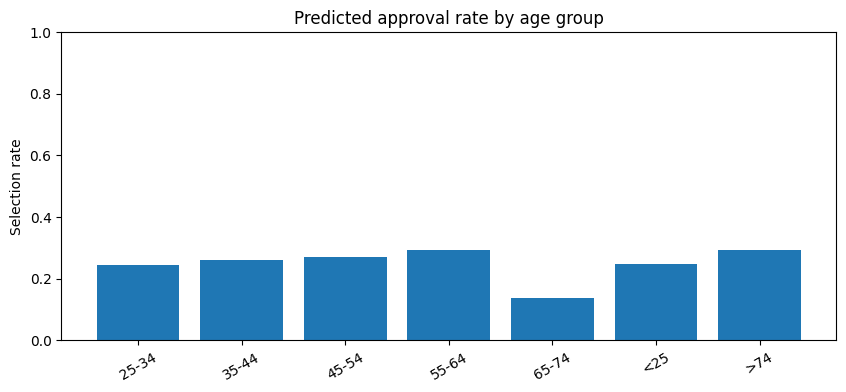

In [26]:
# Create graph for sex-based approval rates
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(sex_fairness["group"], sex_fairness["selection_rate"])
ax.set_title("Predicted approval rate by sex")
ax.set_ylabel("Selection rate")
ax.set_ylim(0, 1)
plt.show()

# Create graph for race-based approval rates
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(race_fairness["group"], race_fairness["selection_rate"])
ax.set_title("Predicted approval rate by race")
ax.set_ylabel("Selection rate")
ax.set_ylim(0, 1)
plt.show()

# Create graph for age-based approval rates
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(age_fairness["group"], age_fairness["selection_rate"])
ax.set_title("Predicted approval rate by age group")
ax.set_ylabel("Selection rate")
ax.set_ylim(0, 1)
plt.xticks(rotation=30)
plt.show()

## 7. Save MMD result tables

Save the results for future reference.


In [27]:
# Output directory paths
sex_fairness_path = OUT_DIR / "mmd_fairness_by_sex.csv"
race_fairness_path = OUT_DIR / "mmd_fairness_by_race.csv"
age_fairness_path = OUT_DIR / "mmd_fairness_by_age.csv"
metrics_path = OUT_DIR / "mmd_model_metrics.csv"

# Convert dataframes to csv
sex_fairness.to_csv(sex_fairness_path, index=False)
race_fairness.to_csv(race_fairness_path, index=False)
age_fairness.to_csv(age_fairness_path, index=False)

# Summarize all baseline metrics into one baseline dataframe
metrics_df = pd.DataFrame([
    {"metric": "accuracy", "value": accuracy_mmd},
    {"metric": "balanced_accuracy", "value": bal_acc_mmd},
    {"metric": "roc_auc", "value": auc_mmd},
    {"metric": "sex_demographic_parity_gap", "value": float(sex_summary['demographic_parity_gap'])},
    {"metric": "sex_equal_opportunity_gap", "value": float(sex_summary['equal_opportunity_gap'])},
    {"metric": "race_demographic_parity_gap", "value": float(race_summary['demographic_parity_gap'])},
    {"metric": "race_equal_opportunity_gap", "value": float(race_summary['equal_opportunity_gap'])},
    {"metric": "age_demographic_parity_gap", "value": float(age_summary['demographic_parity_gap'])},
    {"metric": "age_equal_opportunity_gap", "value": float(age_summary['equal_opportunity_gap'])},
])

# Convert baseline dataframe to csv
metrics_df.to_csv(metrics_path, index=False)

# Print successfull save
print("Saved:")
print(" -", sex_fairness_path)
print(" -", race_fairness_path)
print(" -", age_fairness_path)
print(" -", metrics_path)

Saved:
 - MMD_Distribution_Outputs/mmd_fairness_by_sex.csv
 - MMD_Distribution_Outputs/mmd_fairness_by_race.csv
 - MMD_Distribution_Outputs/mmd_fairness_by_age.csv
 - MMD_Distribution_Outputs/mmd_model_metrics.csv
